In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
import copy
import pandas as pd
import os
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,confusion_matrix, classification_report)
from torchvision import models
from collections import Counter
from thop import profile

In [2]:
transform_train = T.Compose([
    T.RandomRotation(15, fill=[124, 116, 104]),
    T.RandomResizedCrop(256, scale=(0.85, 1.0), ratio=(0.95, 1.05)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.02),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [3]:
train_dataset = torchvision.datasets.ImageFolder(
    root="../../dataset/PlantVillage_split/train",
    transform=transform_train
)

val_dataset = torchvision.datasets.ImageFolder(
    root="../../dataset/PlantVillage_split/val",
    transform=transform_val
)

test_dataset = torchvision.datasets.ImageFolder(
    root="../../dataset/PlantVillage_split/test",
    transform=transform_val
)

In [4]:
counts_train = Counter(train_dataset.targets)
counts_val = Counter(val_dataset.targets)
counts_test = Counter(test_dataset.targets)

splits_dataset = [counts_train, counts_val, counts_test]


for split in splits_dataset:
    if split == counts_train:
        print("Number of images in train")
    elif split == counts_val:
        print("Number of images in val")
    else:
        print("Number of images in test")

    print()

    for idx, count in split.items():
        print(f"Class {idx}: {count}")
    print()

Number of images in train

Class 0: 504
Class 1: 496
Class 2: 220
Class 3: 1316
Class 4: 1201
Class 5: 841
Class 6: 683
Class 7: 410
Class 8: 953
Class 9: 788
Class 10: 929
Class 11: 944
Class 12: 1106
Class 13: 860
Class 14: 338
Class 15: 4405
Class 16: 1837
Class 17: 288
Class 18: 797
Class 19: 1182
Class 20: 800
Class 21: 800
Class 22: 121
Class 23: 296
Class 24: 4072
Class 25: 1468
Class 26: 887
Class 27: 364
Class 28: 1701
Class 29: 800
Class 30: 1527
Class 31: 761
Class 32: 1416
Class 33: 1340
Class 34: 1123
Class 35: 4285
Class 36: 298
Class 37: 1272

Number of images in val

Class 0: 63
Class 1: 63
Class 2: 28
Class 3: 165
Class 4: 151
Class 5: 106
Class 6: 86
Class 7: 52
Class 8: 120
Class 9: 99
Class 10: 117
Class 11: 118
Class 12: 139
Class 13: 108
Class 14: 43
Class 15: 551
Class 16: 230
Class 17: 36
Class 18: 100
Class 19: 148
Class 20: 100
Class 21: 100
Class 22: 16
Class 23: 38
Class 24: 509
Class 25: 184
Class 26: 111
Class 27: 46
Class 28: 213
Class 29: 100
Class 30: 1

In [5]:
batch_size = 64

count_images = torch.tensor([504, 496, 220, 1316, 1201, 841, 683, 410,
    953, 788, 929, 944, 1106, 860, 338, 4405,
    1837, 288, 797, 1182, 800, 800, 121, 296,
    4072, 1468, 887, 364, 1701, 800, 1527, 761,
    1416, 1340, 1123, 4285, 298, 1272
], dtype=torch.float32)

class_weights = 1.0 / torch.sqrt(count_images)

sample_weights = [class_weights[label]for label in train_dataset.targets]

sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

trainloader = DataLoader(
                        train_dataset,
                        batch_size=batch_size,
                        sampler=sampler,
                        pin_memory=True,
                        num_workers=0,
                        persistent_workers=False,
                        drop_last=False)

valloader = DataLoader(val_dataset, 
                       batch_size=batch_size * 2, 
                       shuffle=False, 
                       pin_memory=True, 
                       num_workers=0, 
                       persistent_workers=False)

testloader = DataLoader(test_dataset, 
                        batch_size=batch_size * 2, 
                        shuffle=False, 
                        pin_memory=True, 
                        num_workers=0, 
                        persistent_workers=False)

In [6]:
class PlantDisease_ResNet50(nn.Module):
    def __init__(self, num_class=38, freeze_backbone=False):
        super().__init__()

        self.backbone = models.resnet50(weights="IMAGENET1K_V1")

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        in_features = self.backbone.fc.in_features

        self.backbone.fc = nn.Linear(in_features, num_class)

    def forward(self, x):
        return self.backbone(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PlantDisease_ResNet50(num_class=38, freeze_backbone=True)
model = model.to(device)
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

In [7]:
if device.type == "cuda":
    print("Training with CUDA")
else:
    print("Training with CPU")

Training with CUDA


In [8]:
model_dir = Path("../../model/resnet50")
checkpoint_path = model_dir / "PlantVillage_ResNet50_checkpoint.pth"
best_weights_path = model_dir / "PlantVillage_ResNet50_best_weights.pth"

n_epochs = 200
early_stopping = 10

if checkpoint_path.exists():
    print(f"\033[94m[INFO]\033[0m Resuming training from {checkpoint_path}")

    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

    start_epoch = checkpoint["epoch"] + 1

    model.load_state_dict(checkpoint["model_state_dict"])

    if start_epoch > 5:
        print(f"\033[94m[INFO]\033[0m Continuing fine-tuning phase.")

        for param in model.backbone.parameters():
            param.requires_grad = True

        backbone_params = [p for n, p in model.backbone.named_parameters() if not n.startswith("fc.")]

        fc_params = model.backbone.fc.parameters()

        optimizer = optim.AdamW(
            [
                {"params": backbone_params, "lr": 5e-6},
                {"params": fc_params, "lr": 5e-5}
            ],
            weight_decay=1e-4
        )

        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25, eta_min=1e-6)

        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    else:
        print(f"\033[94m[INFO]\033[0m Continuing frozen phase.")

        optimizer = optim.AdamW(model.backbone.fc.parameters(), lr=3e-4, weight_decay=1e-4)

        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5, eta_min=1e-6)

        scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

    best_macro_f1 = checkpoint['best_macro_f1']
    best_weights = checkpoint['best_weights']
    best_epoch = checkpoint['best_epoch']

    train_loss_hist = checkpoint['train_loss_hist']
    train_acc_hist = checkpoint['train_acc_hist']
    train_precision_hist = checkpoint['train_precision_hist']
    train_recall_hist = checkpoint['train_recall_hist']
    train_macro_f1_hist = checkpoint['train_macro_f1_hist']

    val_loss_hist = checkpoint['val_loss_hist']
    val_acc_hist = checkpoint['val_acc_hist']
    val_precision_hist = checkpoint['val_precision_hist']
    val_recall_hist = checkpoint['val_recall_hist']
    val_macro_f1_hist = checkpoint['val_macro_f1_hist']
    
    print(f"\033[94m[INFO]\033[0m Ready to continue from the {start_epoch} epoch.")

else:
    start_epoch = 0
    best_macro_f1 = -1
    best_weights = None
    best_epoch = -1

    train_loss_hist = []
    train_acc_hist = []
    train_precision_hist = []
    train_recall_hist = []
    train_macro_f1_hist = []

    val_loss_hist = []
    val_acc_hist = []
    val_precision_hist = []
    val_recall_hist = []
    val_macro_f1_hist = []

    optimizer = optim.AdamW(model.backbone.fc.parameters(), lr=3e-4, weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5, eta_min=1e-6)

    print("\033[91m[ERROR]\033[0m No checkpoint found\n")
    print("\033[94m[INFO]\033[0m Starting training from scratch")

try:
    for epoch in range(start_epoch, n_epochs):
        if epoch == 5 and start_epoch <= 5:
            print(f"\033[94m[INFO]\033[0m Unfreezing backbone for fine-tuning.")

            for param in model.backbone.parameters():
                param.requires_grad = True
            
            backbone_params = [p for n, p in model.backbone.named_parameters()if not n.startswith("fc.")]
            
            fc_params = model.backbone.fc.parameters()
            
            optimizer = optim.AdamW(
                [
                    {"params": backbone_params, "lr": 5e-6},
                    {"params": fc_params, "lr": 5e-5}
                ],
                weight_decay=1e-4
            )
            
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25, eta_min=1e-6)

        train_loss_total = 0.0
        train_samples = 0
        train_y_true_all, train_y_pred_all = [], []

        model.train()

        with tqdm(trainloader, unit="batch") as bar:
            bar.set_description(f"Epoch {epoch}")

            for X_batch, y_batch in bar:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                y_pred = model(X_batch)
                loss = loss_fn(y_pred, y_batch)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                predictions = torch.argmax(y_pred, dim=1)

                train_loss_total += loss.item() * X_batch.size(0)
                train_samples += X_batch.size(0)

                train_y_true_all.extend(y_batch.cpu().numpy())
                train_y_pred_all.extend(predictions.cpu().numpy())

                batch_acc = (predictions == y_batch).float().mean().item()

                bar.set_postfix(loss=loss.item(), acc=batch_acc)

        train_loss = train_loss_total / train_samples
        
        train_acc = accuracy_score(train_y_true_all, train_y_pred_all)
        train_precision = precision_score(train_y_true_all, train_y_pred_all, average="macro", zero_division=0)
        train_recall = recall_score(train_y_true_all, train_y_pred_all, average="macro", zero_division=0)
        train_macro_f1 = f1_score(train_y_true_all, train_y_pred_all, average="macro", zero_division=0)

        train_loss_hist.append(train_loss)
        train_acc_hist.append(train_acc)
        train_precision_hist.append(train_precision)
        train_recall_hist.append(train_recall)
        train_macro_f1_hist.append(train_macro_f1)

        model.eval()
        val_loss_total = 0.0
        val_samples = 0
        val_y_true_all, val_y_pred_all = [], []

        with torch.no_grad():
            for X_batch, y_batch in valloader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                y_pred = model(X_batch)
                loss = loss_fn(y_pred, y_batch)

                predictions = torch.argmax(y_pred, dim=1)
                
                val_loss_total += loss.item() * X_batch.size(0)
                val_samples += X_batch.size(0)
                
                val_y_true_all.extend(y_batch.cpu().numpy())
                val_y_pred_all.extend(predictions.cpu().numpy())

        val_loss = val_loss_total / val_samples

        val_acc = accuracy_score(val_y_true_all, val_y_pred_all)
        val_precision = precision_score(val_y_true_all, val_y_pred_all, average="macro", zero_division=0)
        val_recall = recall_score(val_y_true_all, val_y_pred_all, average="macro", zero_division=0)
        val_macro_f1 = f1_score(val_y_true_all, val_y_pred_all, average="macro", zero_division=0)

        val_loss_hist.append(val_loss)
        val_acc_hist.append(val_acc)
        val_precision_hist.append(val_precision)
        val_recall_hist.append(val_recall)
        val_macro_f1_hist.append(val_macro_f1)

        scheduler.step()

        if val_macro_f1 > best_macro_f1:
            best_macro_f1 = val_macro_f1
            best_epoch = epoch
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, best_weights_path)

            print(f"\033[94m[INFO]\033[0m Best Macro F1 with value {best_macro_f1 * 100:.4f} in the epoch {best_epoch}")

        checkpoint = {"epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "best_macro_f1": best_macro_f1,
            "best_weights": best_weights,
            "best_epoch": best_epoch,
            "train_loss_hist": train_loss_hist,
            "train_acc_hist": train_acc_hist,
            "train_precision_hist": train_precision_hist,
            "train_recall_hist": train_recall_hist,
            "train_macro_f1_hist": train_macro_f1_hist,
            "val_loss_hist": val_loss_hist,
            "val_acc_hist": val_acc_hist,
            "val_precision_hist": val_precision_hist,
            "val_recall_hist": val_recall_hist,
            "val_macro_f1_hist": val_macro_f1_hist}

        torch.save(checkpoint, checkpoint_path)

        if epoch > 5 and (epoch - best_epoch >= early_stopping):
            break

        print(f"Epoch {epoch} | Validation Macro F1 = {val_macro_f1*100:.2f}% | Validation Loss = {val_loss:.2f} | Val Accuracy = {val_acc*100:.2f}%")

    print(f"\033[94m[INFO]\033[0m Best model saved with Macro F1 = {best_macro_f1*100:.4f}%")

except KeyboardInterrupt:
    print("\033[93m[WARNING]\033[0m Training stopped manually")

[INFO] Resuming training from ../../model/resnet50/PlantVillage_ResNet50_checkpoint.pth
[INFO] Continuing fine-tuning phase.
[INFO] Ready to continue from the 56 epoch.


Epoch 56: 100%|██████████| 679/679 [08:11<00:00,  1.38batch/s, acc=1, loss=0.681]    


Epoch 56 | Validation Macro F1 = 99.62% | Validation Loss = 0.69 | Val Accuracy = 99.76%


Epoch 57: 100%|██████████| 679/679 [07:55<00:00,  1.43batch/s, acc=1, loss=0.693]    


Epoch 57 | Validation Macro F1 = 99.72% | Validation Loss = 0.69 | Val Accuracy = 99.80%


...

Epoch 61 | Validation Macro F1 = 99.77% | Validation Loss = 0.68 | Val Accuracy = 99.82%


Epoch 62: 100%|██████████| 679/679 [08:02<00:00,  1.41batch/s, acc=1, loss=0.683]    


Epoch 62 | Validation Macro F1 = 99.74% | Validation Loss = 0.68 | Val Accuracy = 99.82%


Epoch 63: 100%|██████████| 679/679 [08:09<00:00,  1.39batch/s, acc=1, loss=0.682]    


[INFO] Best model saved with Macro F1 = 99.8167%


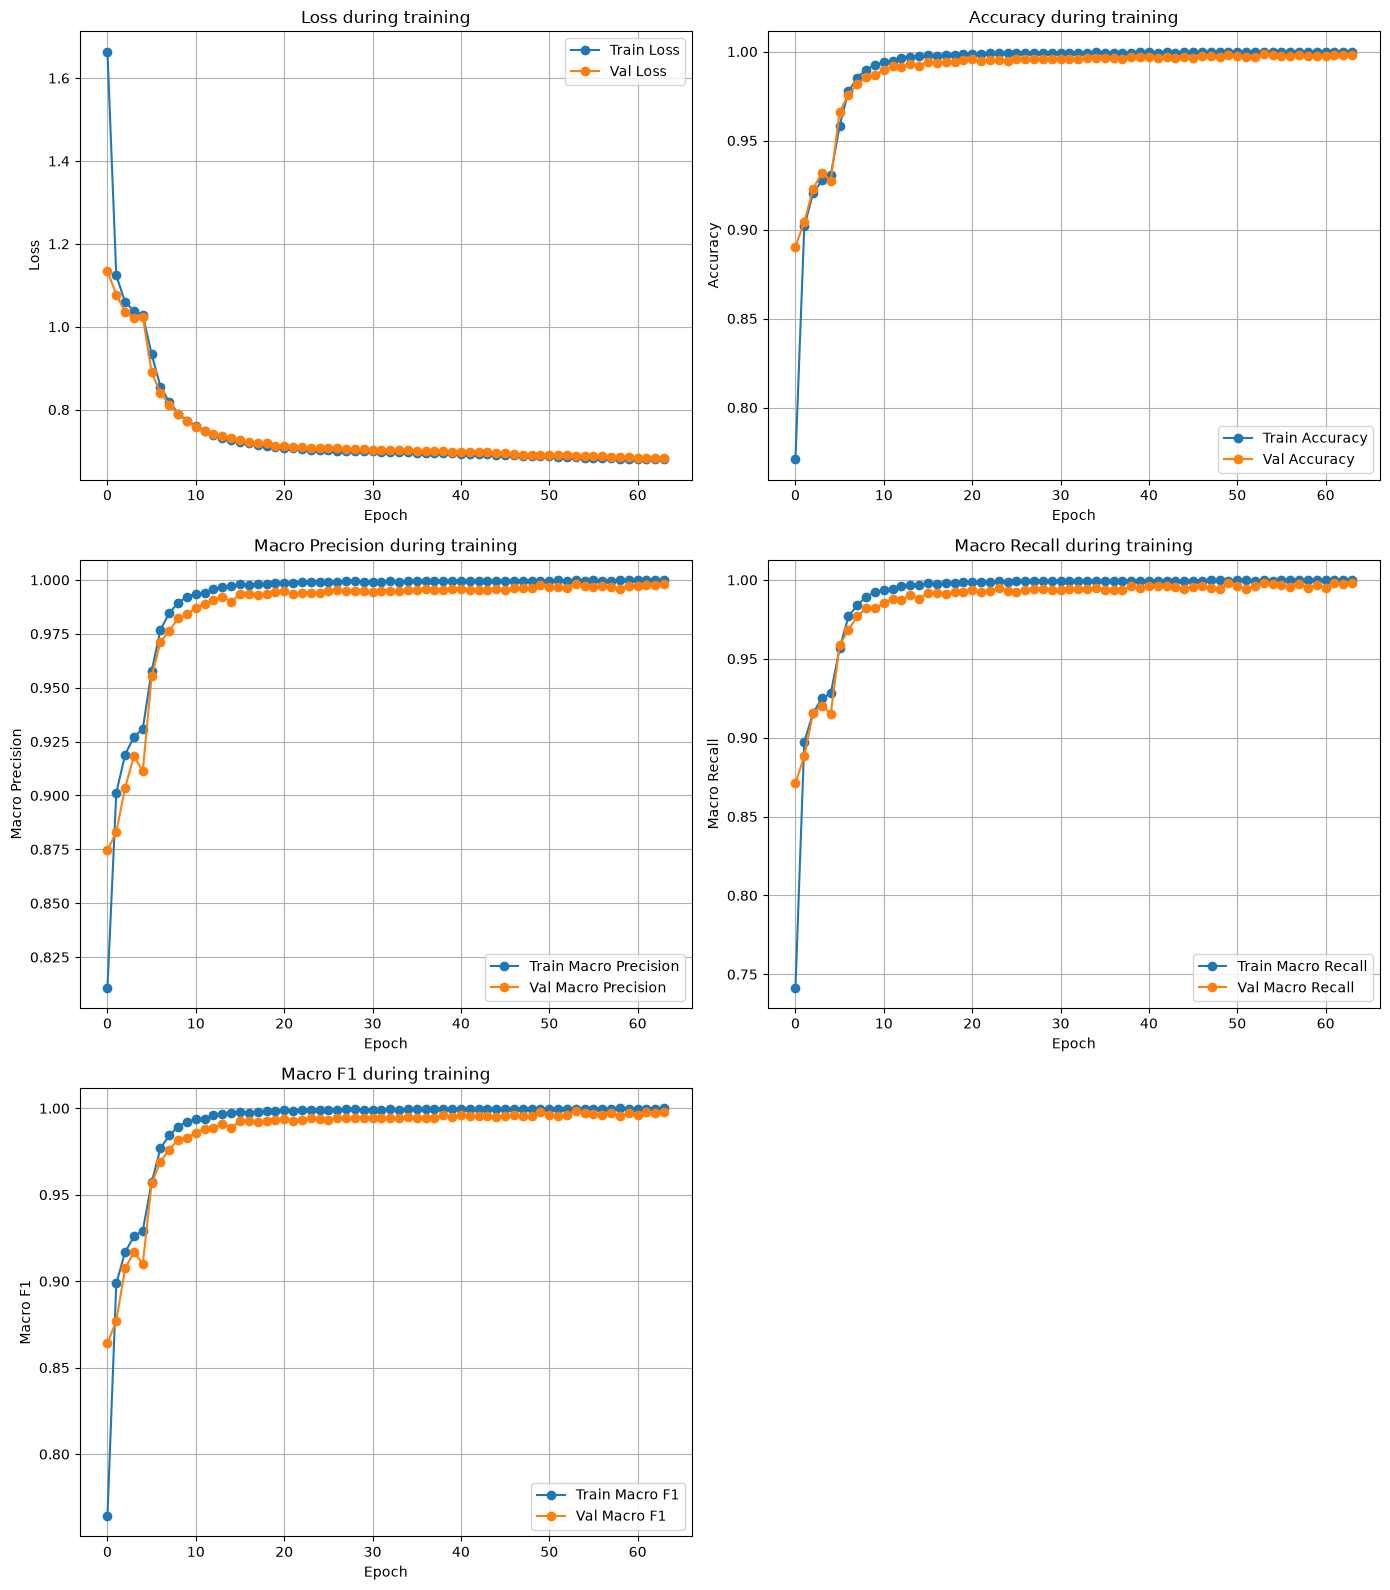

In [9]:
model_dir = Path("../../model/resnet50")
checkpoint_path = model_dir / "PlantVillage_ResNet50_checkpoint.pth"
checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
epochs = range(0, len(checkpoint['train_acc_hist']))

plt.figure(figsize=(14, 16))

# ==========================================
# 1. LOSS
# ==========================================

plt.subplot(3, 2, 1)
plt.plot(epochs, checkpoint["train_loss_hist"], label="Train Loss", marker="o")
plt.plot(epochs, checkpoint["val_loss_hist"], label="Val Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss during training")
plt.legend()
plt.grid(True)

# ==========================================
# 2. ACCURACY
# ==========================================

plt.subplot(3, 2, 2)
plt.plot(epochs, checkpoint["train_acc_hist"],label="Train Accuracy", marker="o")
plt.plot(epochs, checkpoint["val_acc_hist"], label="Val Accuracy", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy during training")
plt.legend()
plt.grid(True)

# ==========================================
# 3. MACRO PRECISION
# ==========================================

plt.subplot(3, 2, 3)
plt.plot(epochs, checkpoint["train_precision_hist"], label="Train Macro Precision", marker="o")
plt.plot(epochs, checkpoint["val_precision_hist"], label="Val Macro Precision", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Macro Precision")
plt.title("Macro Precision during training")
plt.legend()
plt.grid(True)

# ==========================================
# 4. MACRO RECALL
# ==========================================

plt.subplot(3, 2, 4)
plt.plot(epochs, checkpoint["train_recall_hist"], label="Train Macro Recall", marker="o")
plt.plot(epochs, checkpoint["val_recall_hist"], label="Val Macro Recall", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Macro Recall")
plt.title("Macro Recall during training")
plt.legend()
plt.grid(True)

# ==========================================
# 5. MACRO F1
# ==========================================

plt.subplot(3, 2, 5)
plt.plot(epochs, checkpoint["train_macro_f1_hist"], label="Train Macro F1", marker="o")
plt.plot(epochs, checkpoint["val_macro_f1_hist"], label="Val Macro F1", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Macro F1 during training")
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()

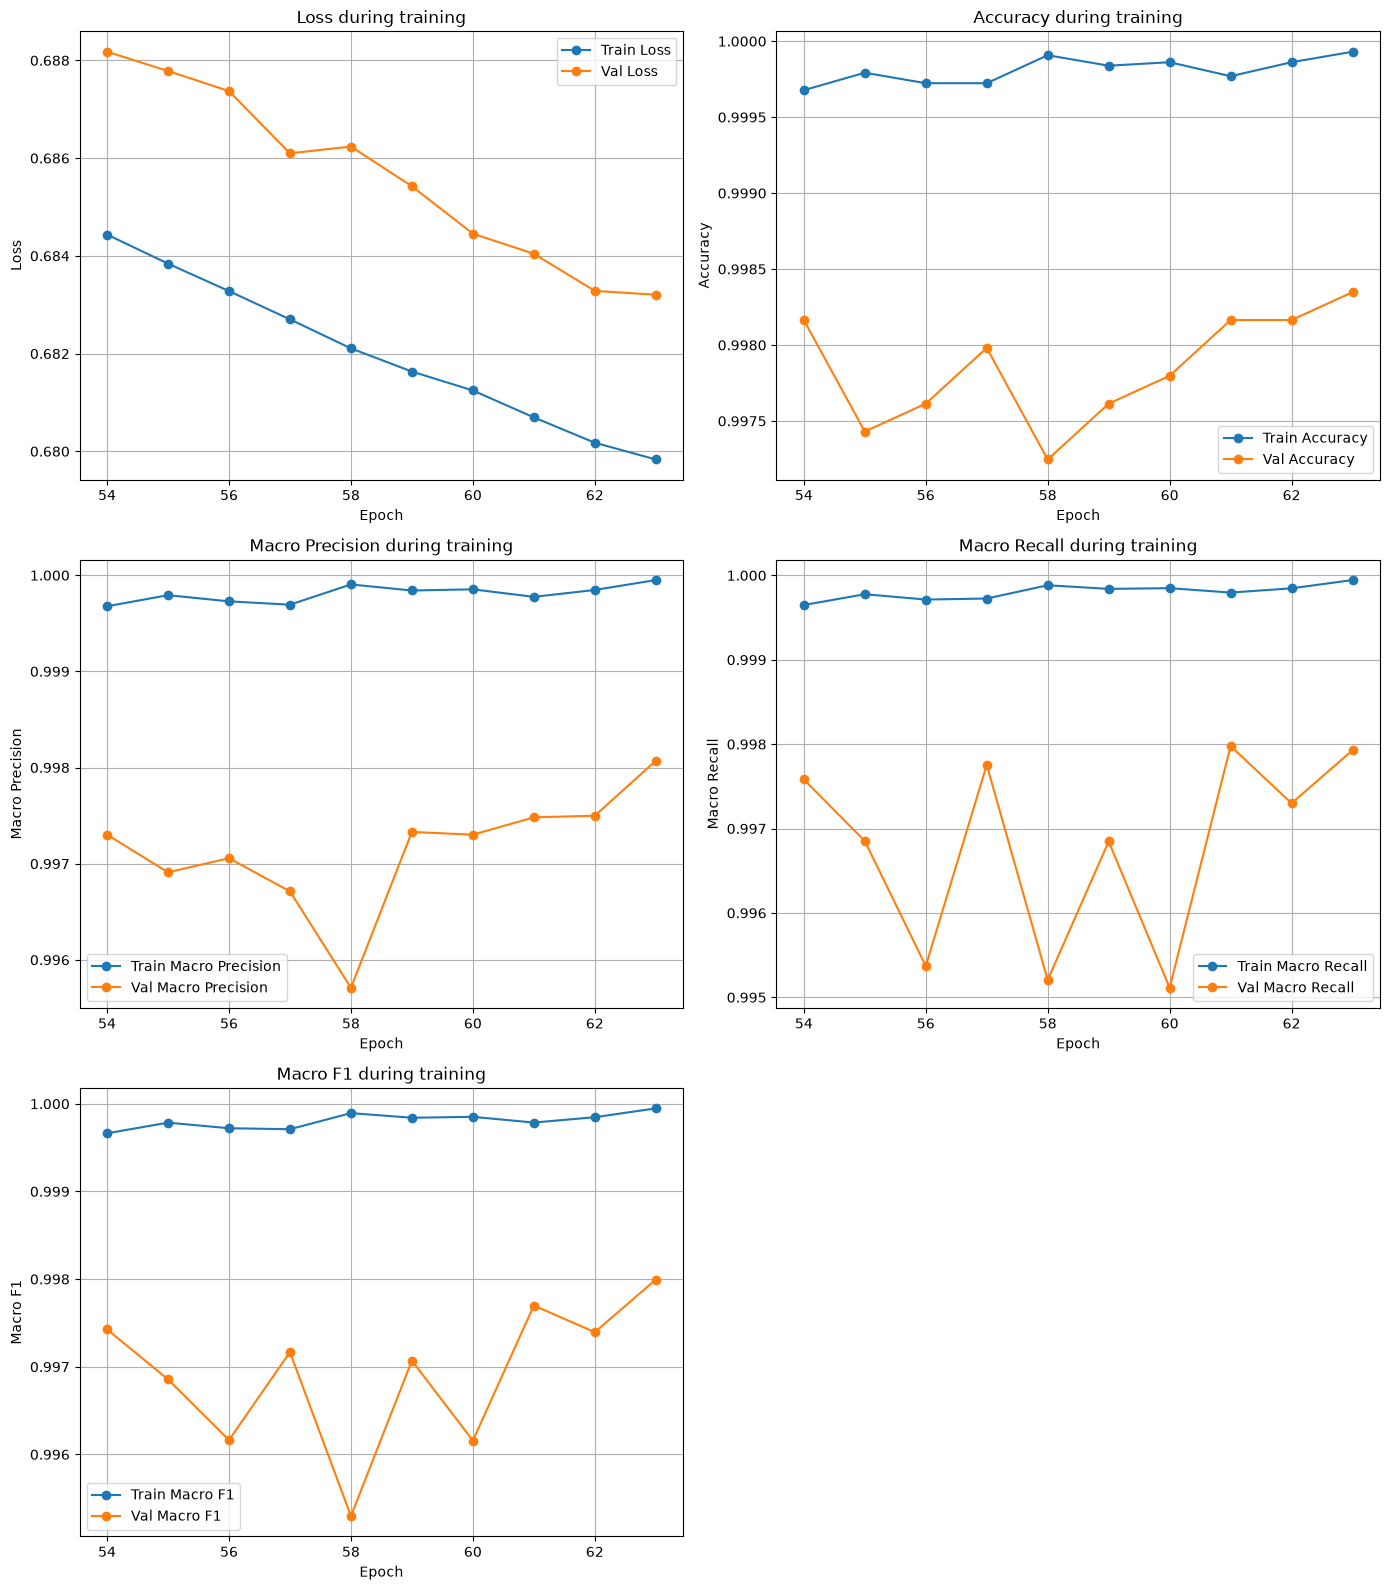

In [10]:
model_dir = Path("../../model/resnet50")
checkpoint_path = model_dir / "PlantVillage_ResNet50_checkpoint.pth"
checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
distance = 10
epochs = range(checkpoint['epoch'] - distance + 1, checkpoint['epoch'] + 1)

plt.figure(figsize=(14, 16))

# ==========================================
# 1. LOSS
# ==========================================

plt.subplot(3, 2, 1)
plt.plot(epochs, checkpoint["train_loss_hist"][-distance:], label="Train Loss", marker="o")
plt.plot(epochs, checkpoint["val_loss_hist"][-distance:], label="Val Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss during training")
plt.legend()
plt.grid(True)

# ==========================================
# 2. ACCURACY
# ==========================================

plt.subplot(3, 2, 2)
plt.plot(epochs, checkpoint["train_acc_hist"][-distance:], label="Train Accuracy", marker="o")
plt.plot(epochs, checkpoint["val_acc_hist"][-distance:], label="Val Accuracy", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy during training")
plt.legend()
plt.grid(True)

# ==========================================
# 3. MACRO PRECISION
# ==========================================

plt.subplot(3, 2, 3)
plt.plot(epochs, checkpoint["train_precision_hist"][-distance:], label="Train Macro Precision", marker="o")
plt.plot(epochs, checkpoint["val_precision_hist"][-distance:], label="Val Macro Precision", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Macro Precision")
plt.title("Macro Precision during training")
plt.legend()
plt.grid(True)

# ==========================================
# 4. MACRO RECALL
# ==========================================

plt.subplot(3, 2, 4)
plt.plot(epochs, checkpoint["train_recall_hist"][-distance:], label="Train Macro Recall", marker="o")
plt.plot(epochs, checkpoint["val_recall_hist"][-distance:], label="Val Macro Recall", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Macro Recall")
plt.title("Macro Recall during training")
plt.legend()
plt.grid(True)

# ==========================================
# 5. MACRO F1
# ==========================================

plt.subplot(3, 2, 5)
plt.plot(epochs, checkpoint["train_macro_f1_hist"][-distance:], label="Train Macro F1", marker="o")
plt.plot(epochs, checkpoint["val_macro_f1_hist"][-distance:], label="Val Macro F1", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Macro F1 during training")
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()

In [11]:
total_params = sum(p.numel() for p in model.parameters())
total_params_m = total_params / 1e6

dummy_input = torch.randn(1, 3, 256, 256).to(device)

flops, params = profile(model, inputs=(dummy_input,), verbose=False)

gflops = flops / 1e9

model_size_mb = os.path.getsize(best_weights_path) / (1024 ** 2)

print(f"Parameters: {total_params_m:.2f} M")
print(f"GFLOPs: {gflops:.2f}")
print(f"Model size: {model_size_mb:.2f} MB")

Parameters: 23.59 M
GFLOPs: 5.40
Model size: 90.29 MB


In [12]:
model = PlantDisease_ResNet50(num_class=38)
model.load_state_dict(torch.load("../../model/resnet50/PlantVillage_ResNet50_best_weights.pth", map_location=device))
model.to(device)

PlantDisease_ResNet50(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (relu): ReLU

In [13]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch , y_batch in testloader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

In [14]:
accuracy = accuracy_score(all_labels, all_preds)

macro_precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)

macro_recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)

macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Test Macro Precision: {macro_precision * 100:.2f}%")
print(f"Test Macro Recall: {macro_recall * 100:.2f}%")
print(f"Test Macro F1: {macro_f1 * 100:.2f}%")

Test Accuracy: 99.87%
Test Macro Precision: 99.69%
Test Macro Recall: 99.82%
Test Macro F1: 99.75%


In [15]:
class_names = test_dataset.classes

report = classification_report(all_labels, all_preds, target_names=class_names, digits=4, zero_division=0)

print(report)

                                               precision    recall  f1-score   support

                           Apple___Apple_scab     1.0000    1.0000    1.0000        63
                            Apple___Black_rot     1.0000    1.0000    1.0000        62
                     Apple___Cedar_apple_rust     1.0000    1.0000    1.0000        27
                              Apple___healthy     1.0000    1.0000    1.0000       164
                          Blueberry___healthy     1.0000    1.0000    1.0000       150
                      Cherry___Powdery_mildew     1.0000    1.0000    1.0000       105
                             Cherry___healthy     1.0000    1.0000    1.0000        85
   Corn___Cercospora_leaf_spot Gray_leaf_spot     0.9259    0.9804    0.9524        51
                           Corn___Common_rust     1.0000    1.0000    1.0000       119
                  Corn___Northern_Leaf_Blight     0.9895    0.9592    0.9741        98
                               Corn___heal

In [16]:
cm = confusion_matrix(all_labels, all_preds)
cm

array([[ 63,   0,   0, ...,   0,   0,   0],
       [  0,  62,   0, ...,   0,   0,   0],
       [  0,   0,  27, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ..., 535,   0,   0],
       [  0,   0,   0, ...,   0,  37,   0],
       [  0,   0,   0, ...,   0,   0, 159]], shape=(38, 38))

In [17]:
label_class_dicc = train_dataset.class_to_idx
plant_disease = []

for disease, _ in label_class_dicc.items():
    plant_disease.append(disease)

plant_disease

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry___Powdery_mildew',
 'Cherry___healthy',
 'Corn___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn___Common_rust',
 'Corn___Northern_Leaf_Blight',
 'Corn___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Lea

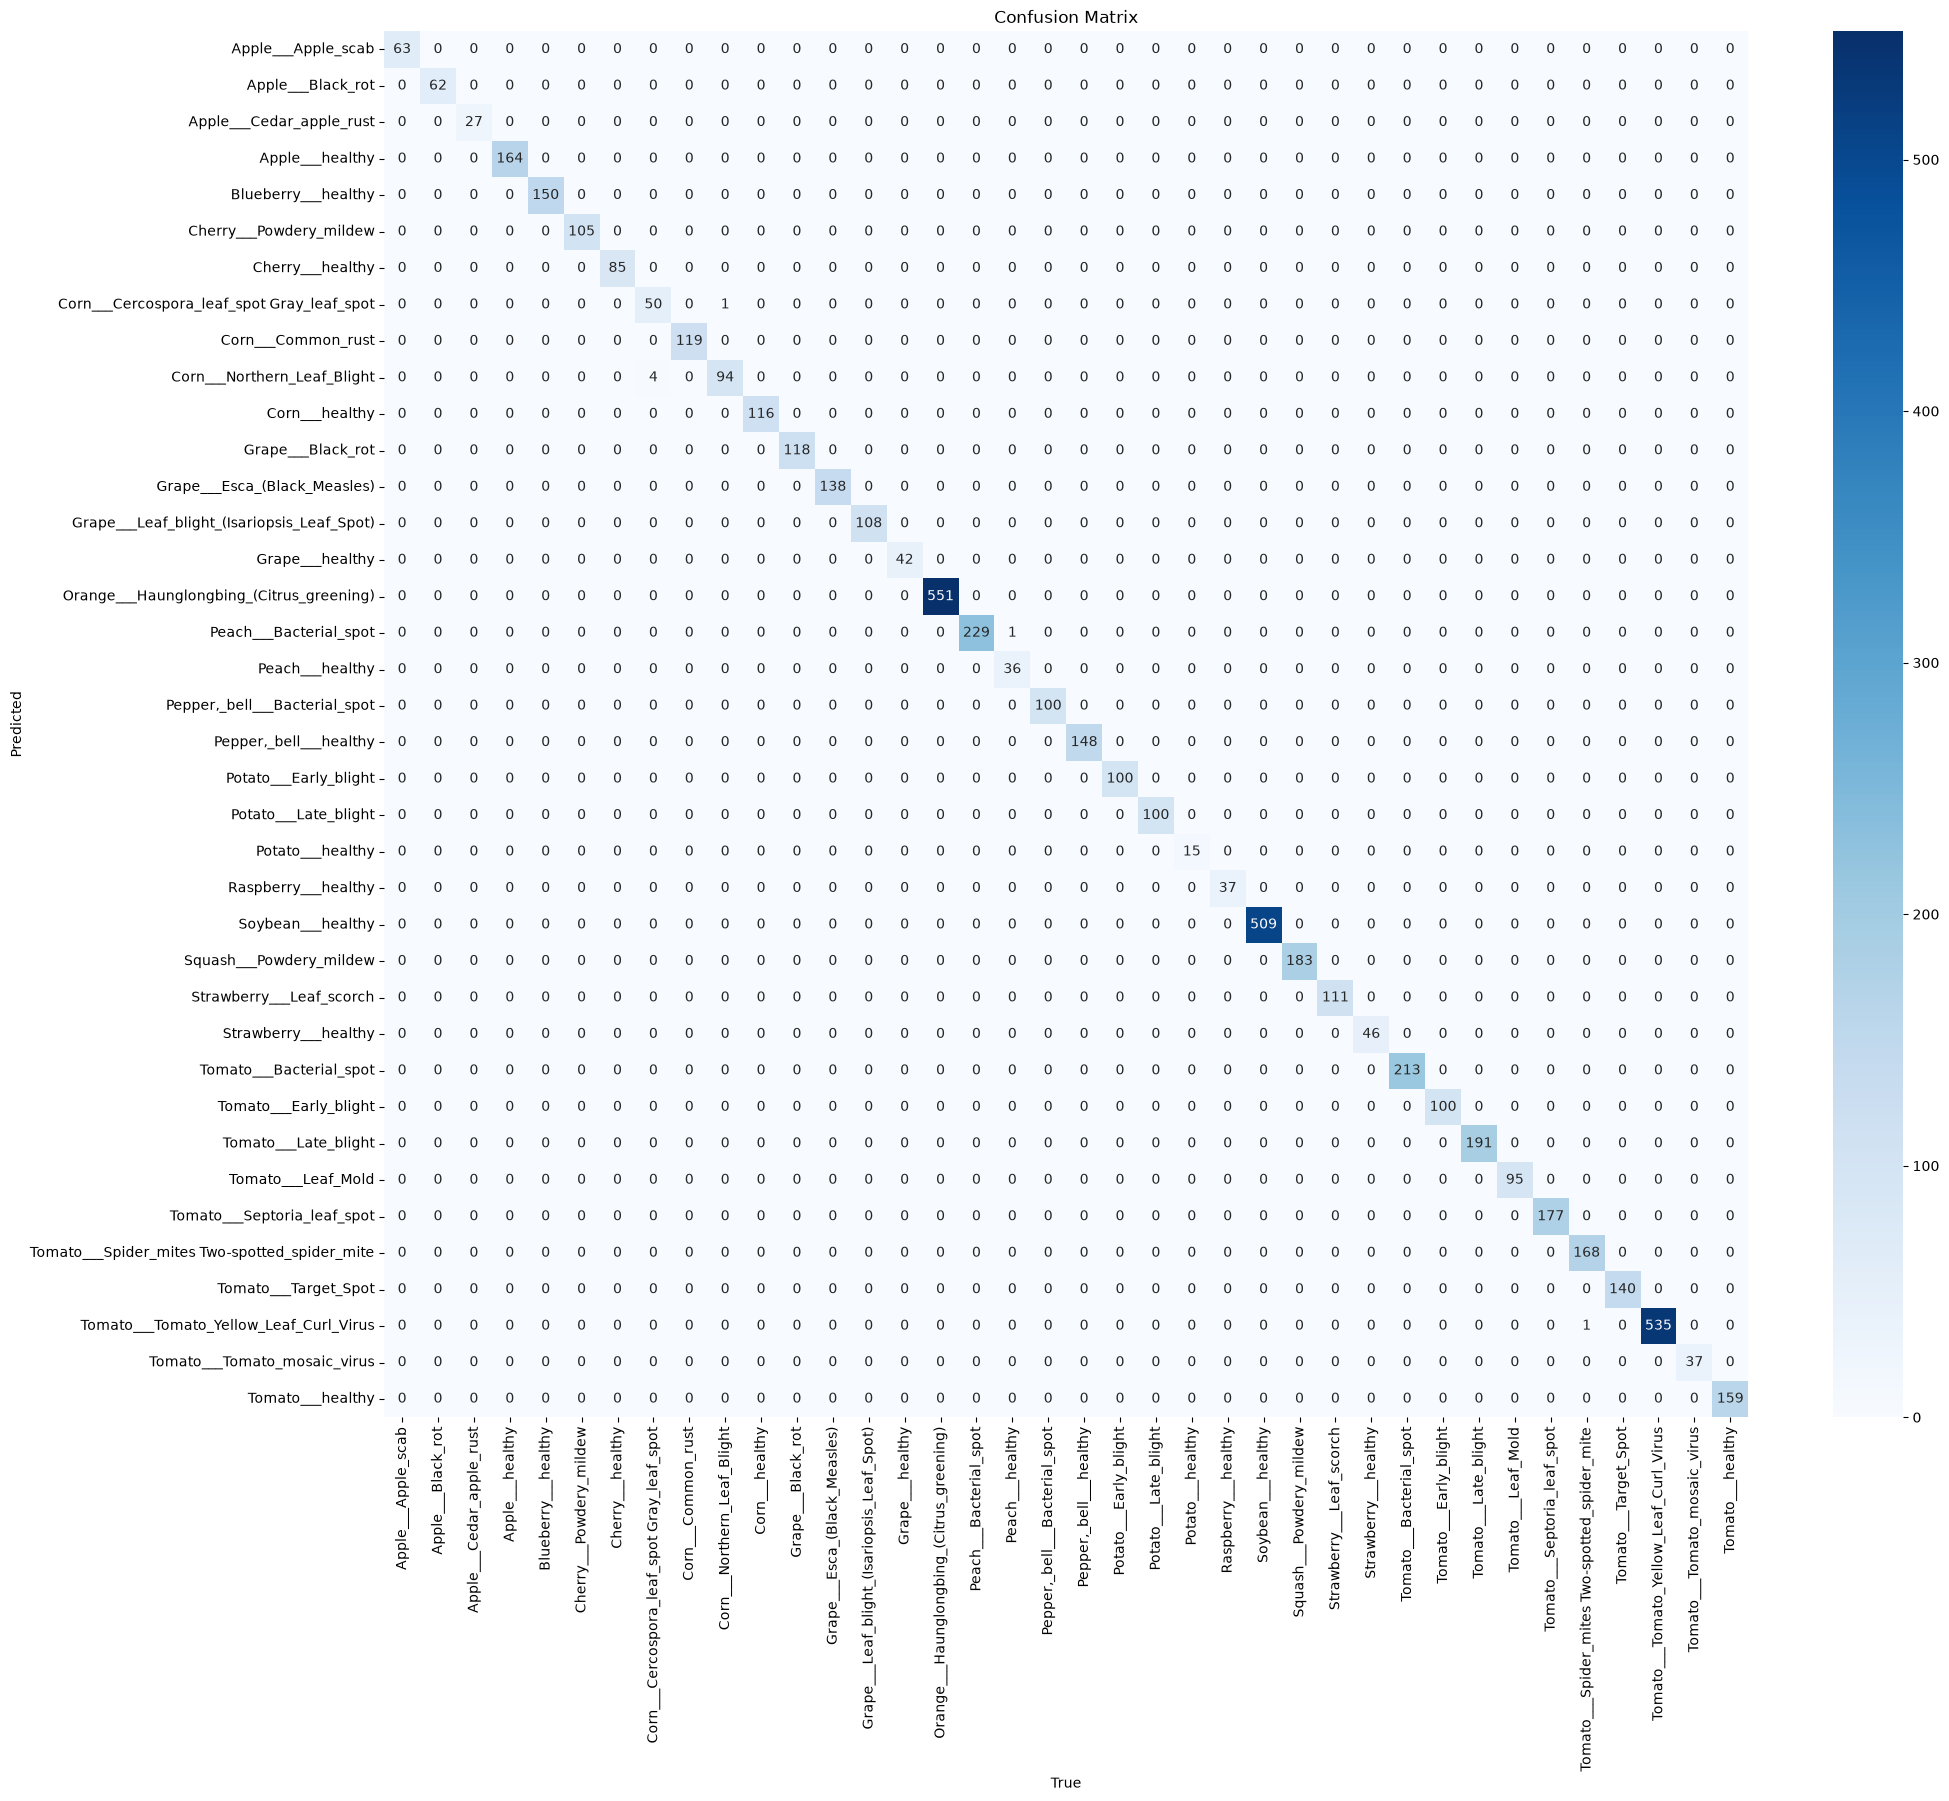

In [18]:
plt.figure(figsize=(22, 18), dpi=100)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=plant_disease, yticklabels=plant_disease, cmap='Blues')
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [19]:
results_path = Path("../../results")
results_path.mkdir(parents=True, exist_ok=True)
test_csv = results_path / "benchmark_results.csv"

columns = ["Model", "Accuracy", "Macro_Precision", "Macro_Recall", "Macro_F1", "Parameters_M", "GFLOPs", "Model_Size_MB"]

if not test_csv.exists():
    pd.DataFrame(columns=columns).to_csv(test_csv, index=False)

print(f"Results file: {test_csv}")

Results file: ../../results/benchmark_results.csv


In [20]:
test_row = {
    "Model": "ResNet50",
    "Accuracy": accuracy * 100,
    "Macro_Precision": macro_precision * 100,
    "Macro_Recall": macro_recall * 100,
    "Macro_F1": macro_f1 * 100,
    "Parameters_M": total_params_m,
    "GFLOPs": gflops,
    "Model_Size_MB": model_size_mb
}

df_test = pd.read_csv(test_csv)

mask = df_test["Model"] == test_row["Model"]

if mask.any():
    for column, value in test_row.items():
        df_test.loc[mask, column] = value
else:
    df_test = pd.concat([df_test, pd.DataFrame([test_row])], ignore_index=True)

df_test.to_csv(test_csv, index=False)

In [21]:
df_test

,Model,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Parameters_M,GFLOPs,Model_Size_MB
0,ResNet18,99.778924,99.656463,99.772152,99.710736,11.196006,2.381762,42.789927
1,ResNet34,99.834193,99.799221,99.800884,99.799473,21.304166,4.804235,81.411662
2,ResNet50,99.871039,99.690672,99.824638,99.754463,23.585894,5.396576,90.288850


In [22]:
train_val_csv = results_path / "train_val_results.csv"

columns_train_val = [
    "Model",
    "Best_Epoch",
    "Train_Loss",
    "Train_Accuracy",
    "Train_Macro_Precision",
    "Train_Macro_Recall",
    "Train_Macro_F1",
    "Val_Loss",
    "Val_Accuracy",
    "Val_Macro_Precision",
    "Val_Macro_Recall",
    "Val_Macro_F1"
]

if not train_val_csv.exists():
    pd.DataFrame(columns=columns_train_val).to_csv(train_val_csv, index=False)

print(f"Results file: {train_val_csv}")

Results file: ../../results/train_val_results.csv


In [23]:
best_epoch = checkpoint["best_epoch"]

train_val_row = {
    "Model": "ResNet50",
    "Best_Epoch": best_epoch,
    "Train_Loss": checkpoint["train_loss_hist"][best_epoch],
    "Train_Accuracy": checkpoint["train_acc_hist"][best_epoch] * 100,
    "Train_Macro_Precision": checkpoint["train_precision_hist"][best_epoch] * 100,
    "Train_Macro_Recall": checkpoint["train_recall_hist"][best_epoch] * 100,
    "Train_Macro_F1": checkpoint["train_macro_f1_hist"][best_epoch] * 100,
    "Val_Loss": checkpoint["val_loss_hist"][best_epoch],
    "Val_Accuracy": checkpoint["val_acc_hist"][best_epoch] * 100,
    "Val_Macro_Precision": checkpoint["val_precision_hist"][best_epoch] * 100,
    "Val_Macro_Recall": checkpoint["val_recall_hist"][best_epoch] * 100,
    "Val_Macro_F1": checkpoint["val_macro_f1_hist"][best_epoch] * 100
}

df_train_val = pd.read_csv(train_val_csv)

mask = df_train_val["Model"] == train_val_row["Model"]

if mask.any():
    for column, value in train_val_row.items():
        df_train_val.loc[mask, column] = value
else:
    df_train_val = pd.concat([df_train_val, pd.DataFrame([train_val_row])], ignore_index=True)

df_train_val.to_csv(train_val_csv, index=False)

In [24]:
df_train_val

,Model,Best_Epoch,Train_Loss,Train_Accuracy,Train_Macro_Precision,Train_Macro_Recall,Train_Macro_F1,Val_Loss,Val_Accuracy,Val_Macro_Precision,Val_Macro_Recall,Val_Macro_F1
0,ResNet18,55,0.707548,99.907896,99.903039,99.907417,99.905176,0.711020,99.687959,99.557337,99.482408,99.507075
1,ResNet34,73,0.678019,99.988487,99.989005,99.987852,99.988420,0.681462,99.834802,99.783926,99.652242,99.713531
2,ResNet50,53,0.684625,99.983882,99.983873,99.985497,99.984675,0.687182,99.853157,99.826054,99.808537,99.816746
